# Set Up

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Data Set

In [2]:
df = pd.read_csv("DATA/PROCESSED/final_streaming_dataset.csv")

print(df.shape)
df.head()

(96200, 77)


,genre_names,origin_country,engagement_score,original_language,popularity_norm,genre_ids,title_age,tmdb_id,freshness_score,original_title,...,topic_religion_spirituality,topic_animation_family,topic_friendship,topic_revenge,topic_road_trip_journey,topic_school_university,topic_work_business,topic_diversity_score,cluster,cluster_label
0,"Crime, Drama, Comedy",US,7.789985,English,0.916136,"[80, 18, 35]",8.0,79744.0,0.922481,The Rookie,...,0,0,0,0,0,0,1,3,2,High Visibility
1,"Action, Science Fiction, Thriller",AU,2.340317,English,1.000000,"[28, 878, 53]",0.0,1265609.0,0.984496,War Machine,...,0,0,0,0,0,0,0,4,2,High Visibility
2,Drama,US,27.603475,English,0.796415,[18],21.0,1416.0,0.821705,Grey's Anatomy,...,0,0,0,0,0,0,0,0,2,High Visibility
3,"Drama, Mystery, Sci-Fi & Fantasy",US,21.134389,English,0.830130,"[18, 9648, 10765]",21.0,1622.0,0.821705,Supernatural,...,0,0,0,0,0,0,0,5,2,High Visibility
4,"Sci-Fi & Fantasy, Drama, Action & Adventure",US,67.621359,English,0.445930,"[10765, 18, 10759]",15.0,1399.0,0.868217,Game of Thrones,...,0,0,0,0,0,0,0,4,2,High Visibility


Purpose

The regression model answers:
- “Can we predict the Business Value Score based on content features?”

This is a supervised learning approach, where the model learns from known outcomes.


# Define Features

1. Define Features and Target

X (features):
- popularity
- vote_count
- vote_average
- release_year
- runtime
- topic features

y (target):
- business_value_score

This defines what the model learns from and what it predicts.


In [3]:
topic_cols = [col for col in df.columns if col.startswith("topic_")]

features = [
    "popularity",
    "vote_count",
    "vote_average",
    "release_year",
    "runtime_final",
    "visibility_score",
    "engagement_score",
    "audience_reception_score",
    "topic_diversity_score"
] + topic_cols

target = "business_value_score"

# Prepare Data

Missing values were filled to ensure a complete dataset for training.

In [4]:
X = df[features].copy()
y = df[target]

# Fill missing values
X = X.fillna(0)
y = y.fillna(y.median())

# Train / Test Split

We split the dataset into:
- Training set → used to train the model
- Test set → used to evaluate performance

This ensures the model can generalize to unseen data.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (76960, 42)
Test shape: (19240, 42)


# Linear Regression

We first used a simple linear regression model.

Purpose:
- establish a baseline
- test if relationships are approximately linear
- provide interpretability


In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# Evaluate Linear Reegression

RSME = AVG prediction error
R^2 = how much variance i explain (closer to 1 better)

These metrics help evaluate how well the model performs.

In [7]:
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R²:", r2_lr)

Linear Regression RMSE: 1.0146675186915506
Linear Regression R²: 0.8170686062107446


# Random Forest

We then trained a Random Forest model.


 Why?
Because relationships between variables are often non-linear, for example:
- popularity may not increase value linearly
- interactions between variables matter


Random Forest captures these complex relationships better.


In [8]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Evaluate Random Forest 

In [9]:
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R²:", r2_rf)

Random Forest RMSE: 0.31660509703933326
Random Forest R²: 0.982189482770179


# Feature Importance 

We extracted feature importance from the Random Forest model.

This tells us:

“Which variables drive business value the most?”

Examples:
- popularity
- engagement
- ratings
- thematic diversity


In [10]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print(importances.head(10))

vote_average                0.373063
audience_reception_score    0.195510
release_year                0.165426
vote_count                  0.124604
popularity                  0.104142
visibility_score            0.022546
engagement_score            0.012911
runtime_final               0.000336
topic_diversity_score       0.000272
topic_diversity_score       0.000260
dtype: float64


plot feature importance 

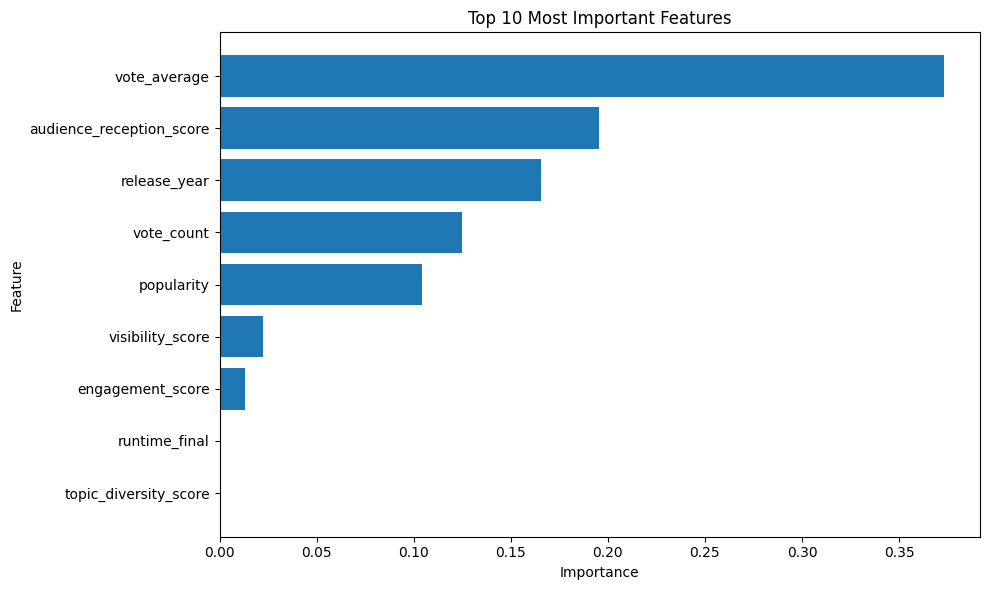

In [11]:
import matplotlib.pyplot as plt

top_features = importances.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features.values[::-1])
plt.title("Top 10 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Compare predictions vs Real

We generated predicted business value scores for all titles.

This allows:
- comparison between actual vs predicted values
- simulation of new content performance


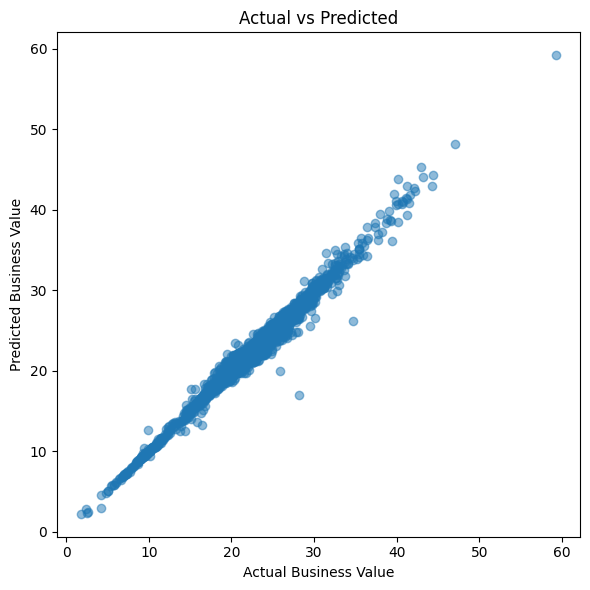

In [12]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Business Value")
plt.ylabel("Predicted Business Value")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

# Save predictions 

In [13]:
df["predicted_business_value"] = rf.predict(X)

df.to_csv("DATA/PROCESSED/final_with_predictions.csv", index=False)

print("Saved: final_with_predictions.csv")

Saved: final_with_predictions.csv


residual analysis

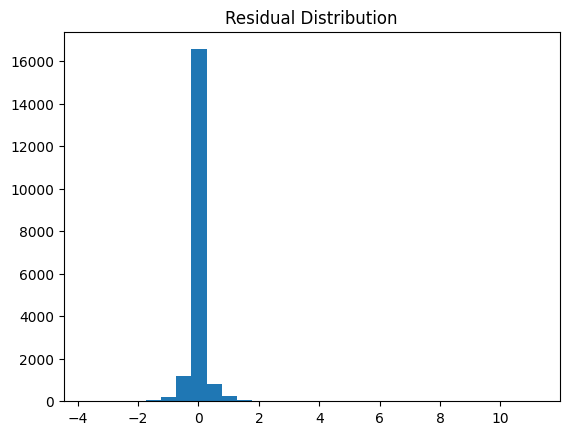

In [14]:
residuals = y_test - y_pred_rf

plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

predict new content 

In [15]:
new_data = X.iloc[:5]
predictions = rf.predict(new_data)

print (predictions)

[62.17835216 57.56846176 61.40655665 62.02191875 59.21243988]


We built a regression model to predict the Business Value Score using content popularity, engagement, ratings, and thematic features extracted from descriptions.
